<div style="text-align: center; padding: 10px; background-color: #1e1e1e; color: white;">
   <h3 style="margin-top: 10px; color: white;">Fundación Universitaria Konrad Lorenz </h3>
   <hr style="width: 60%; margin: 10px auto; border-color: #555;">
   <div style="font-size: 14px; line-height: 1.5;">
       <p><b>Proyecto:</b> Modelado Ticket Promedio</p>
       <p><b>Nombre:</b> Angela Cañón Ballares</p>
       <p><b>Facultad:</b> Maestría en Analítica Estratégica de Datos</p>
       <p><b>Asignatura:</b> Modelos de Machine Learning en Producción: MLOps</p>

   </div>
   <hr style="width: 60%; margin: 10px auto; border-color: #555;">
</div>

## Construcción EDA

---

## Contexto de Negocio

Existe alta variabilidad en el **Average Order Value (AOV)** o **Ticket Promedio** entre sucursales. Este análisis exploratorio tiene como objetivo:

1. **Entender la estructura** de los 4 datasets disponibles y sus relaciones (modelo entidad-relación).
2. **Detectar anomalías y outliers** en la variable target (`total_venta`).
3. **Generar hipótesis** sobre los factores exógenos y endógenos que impulsan el AOV.
4. **Tomar decisiones de feature engineering** para los modelos inferencial y predictivo.

---

## Datasets disponibles

| Dataset | Granularidad | Llave Primaria |
|---|---|---|
| `transacciones_resumen` | 1 fila = 1 ticket de compra | `id_ticket` |
| `clientes_loyalty` | 1 fila = 1 cliente registrado | `id_cliente` |
| `variables_exogenas` | 1 fila = 1 tienda × 1 día | `id_tienda + fecha` |
| `promociones_activas` | 1 fila = 1 promo × tienda | `id_producto + id_tienda + fecha_inicio` |

**Modelo Entidad-Relación:**
```
clientes_loyalty (id_cliente) ──< transacciones_resumen (id_cliente, id_tienda, fecha)
                                         │
                                         ├──> variables_exogenas (id_tienda + fecha)
                                         └──> promociones_activas (id_tienda, vigencia por fecha)
```

**Variable Target:** `total_venta` (AOV = promedio de `total_venta` por cliente/tienda/período)

## 0. Setup — Instalación y Librerías

In [1]:
# ── Instalar dependencias extra (solo necesario en Colab) ──────────────────────
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg in ['plotly', 'scipy', 'statsmodels']:
    try:
        __import__(pkg)
    except ImportError:
        install(pkg)

print('Dependencias OK')

Dependencias OK


In [2]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import statsmodels.api as sm

# Estilo global
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Colores corporativos del análisis
PALETTE = {'Premium': '#2196F3', 'Regular': '#4CAF50', 'Budget': '#FF9800'}
TARGET = 'total_venta'

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y Validación de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Carga de datasets ──────────────────────────────────────────────────────────

tx = pd.read_csv(f'/content/drive/MyDrive/Colab Notebooks/Sem3_MLOps/Trabajo Final/transacciones_resumen.csv', parse_dates=['timestamp'])
cl = pd.read_csv(f'/content/drive/MyDrive/Colab Notebooks/Sem3_MLOps/Trabajo Final/clientes_loyalty.csv', parse_dates=['fecha_registro'])
ex = pd.read_csv(f'/content/drive/MyDrive/Colab Notebooks/Sem3_MLOps/Trabajo Final/variables_exogenas.csv', parse_dates=['fecha'])
pr = pd.read_csv(f'/content/drive/MyDrive/Colab Notebooks/Sem3_MLOps/Trabajo Final/promociones_activas.csv', parse_dates=['fecha_inicio', 'fecha_fin'])


In [ ]:
# Resumen rápido
datasets = {'transacciones_resumen': tx, 'clientes_loyalty': cl,
            'variables_exogenas': ex, 'promociones_activas': pr}

summary = pd.DataFrame({
    'filas': {k: len(v) for k, v in datasets.items()},
    'columnas': {k: len(v.columns) for k, v in datasets.items()},
    'nulos_totales': {k: v.isnull().sum().sum() for k, v in datasets.items()},
    'duplicados': {k: v.duplicated().sum() for k, v in datasets.items()},
})
print('Resumen de datasets:')
display(summary)

Resumen de datasets:


,filas,columnas,nulos_totales,duplicados
transacciones_resumen,10000,6,0,0
clientes_loyalty,1000,4,0,0
variables_exogenas,910,5,0,0
promociones_activas,493,5,0,0


In [ ]:
# ── Tipos de datos y cardinalidades ───────────────────────────────────────────
for name, df in datasets.items():
    print(f'\n{'='*55}')
    print(f' {name}')
    print(f'{'='*55}')
    info = pd.DataFrame({
        'dtype': df.dtypes,
        'nulos': df.isnull().sum(),
        'pct_nulos': (df.isnull().mean() * 100).round(2),
        'únicos': df.nunique(),
        'ejemplo': df.iloc[0]
    })
    display(info)


 transacciones_resumen


,dtype,nulos,pct_nulos,únicos,ejemplo
id_ticket,object,0,0.0,10000,TICKET_0000001
id_tienda,object,0,0.0,10,STORE_10
timestamp,datetime64[ns],0,0.0,9413,2024-03-31 14:27:00
total_venta,float64,0,0.0,3530,3.61
total_articulos,int64,0,0.0,7,1
id_cliente,object,0,0.0,1000,CUST_00647



 clientes_loyalty


,dtype,nulos,pct_nulos,únicos,ejemplo
id_cliente,object,0,0.0,1000,CUST_00001
fecha_registro,datetime64[ns],0,0.0,521,2023-04-30 00:00:00
edad,int64,0,0.0,52,51
segmento,object,0,0.0,3,Regular



 variables_exogenas


,dtype,nulos,pct_nulos,únicos,ejemplo
fecha,datetime64[ns],0,0.0,91,2024-01-01 00:00:00
id_tienda,object,0,0.0,10,STORE_01
clima,object,0,0.0,3,Sunny
competitor_price_index,float64,0,0.0,33,1.01
indice_trafico,float64,0,0.0,550,85.6



 promociones_activas


,dtype,nulos,pct_nulos,únicos,ejemplo
fecha_inicio,datetime64[ns],0,0.0,78,2024-02-07 00:00:00
fecha_fin,datetime64[ns],0,0.0,75,2024-02-18 00:00:00
id_producto,object,0,0.0,49,PROD_034
tipo_descuento,object,0,0.0,3,Fixed_Amount
id_tienda,object,0,0.0,10,STORE_06


In [ ]:
# ── Validación de integridad referencial ──────────────────────────────────────
print('Validación de llaves foráneas:')
print()

# Clientes en TX que existen en CL
clientes_tx = set(tx['id_cliente'].unique())
clientes_cl = set(cl['id_cliente'].unique())
print(f'Clientes en TX: {len(clientes_tx):,}')
print(f'Clientes en CL: {len(clientes_cl):,}')
print(f'TX sin match en CL: {len(clientes_tx - clientes_cl):,}  ← huérfanos')
print(f'CL sin transacciones: {len(clientes_cl - clientes_tx):,}  ← clientes inactivos')
print()

# Tiendas
tiendas_tx = set(tx['id_tienda'].unique())
tiendas_ex = set(ex['id_tienda'].unique())
tiendas_pr = set(pr['id_tienda'].unique())
print(f'Tiendas en TX: {sorted(tiendas_tx)}')
print(f'Tiendas en EX: {sorted(tiendas_ex)}')
print(f'Tiendas en PR: {sorted(tiendas_pr)}')
print(f'TX ∩ EX ∩ PR: {sorted(tiendas_tx & tiendas_ex & tiendas_pr)}')
print()

# Rango temporal
print('Rangos temporales:')
tx['fecha'] = tx['timestamp'].dt.date.astype('datetime64[ns]')
print(f'TX:  {tx["timestamp"].min().date()} → {tx["timestamp"].max().date()}')
print(f'EX:  {ex["fecha"].min().date()} → {ex["fecha"].max().date()}')
print(f'PR:  {pr["fecha_inicio"].min().date()} → {pr["fecha_fin"].max().date()}')
print(f'CL:  registros desde {cl["fecha_registro"].min().date()} → {cl["fecha_registro"].max().date()}')

Validación de llaves foráneas:

Clientes en TX: 1,000
Clientes en CL: 1,000
TX sin match en CL: 0  ← huérfanos
CL sin transacciones: 0  ← clientes inactivos

Tiendas en TX: ['STORE_01', 'STORE_02', 'STORE_03', 'STORE_04', 'STORE_05', 'STORE_06', 'STORE_07', 'STORE_08', 'STORE_09', 'STORE_10']
Tiendas en EX: ['STORE_01', 'STORE_02', 'STORE_03', 'STORE_04', 'STORE_05', 'STORE_06', 'STORE_07', 'STORE_08', 'STORE_09', 'STORE_10']
Tiendas en PR: ['STORE_01', 'STORE_02', 'STORE_03', 'STORE_04', 'STORE_05', 'STORE_06', 'STORE_07', 'STORE_08', 'STORE_09', 'STORE_10']
TX ∩ EX ∩ PR: ['STORE_01', 'STORE_02', 'STORE_03', 'STORE_04', 'STORE_05', 'STORE_06', 'STORE_07', 'STORE_08', 'STORE_09', 'STORE_10']

Rangos temporales:
TX:  2024-01-01 → 2024-03-31
EX:  2024-01-01 → 2024-03-31
PR:  2024-01-01 → 2024-03-31
CL:  registros desde 2022-01-01 → 2023-12-31


## 2. Análisis de la Variable Target — `total_venta` (AOV)

In [ ]:
# ── Estadísticas descriptivas del target ──────────────────────────────────────
desc = tx[TARGET].describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])
print('Estadísticas descriptivas de total_venta:')
print(desc.to_string())
print(f'\nSkewness : {tx[TARGET].skew():.3f}')
print(f'Kurtosis : {tx[TARGET].kurt():.3f}')
print(f'CV (%)   : {tx[TARGET].std() / tx[TARGET].mean() * 100:.1f}%')

Estadísticas descriptivas de total_venta:
count    10000.000000
mean        17.940067
std         11.083411
min          2.190000
1%           2.390000
5%           3.460000
10%          5.549000
25%          9.310000
50%         15.490000
75%         24.362500
90%         33.761000
95%         39.331000
99%         49.530700
max         67.400000

Skewness : 0.898
Kurtosis : 0.510
CV (%)   : 61.8%


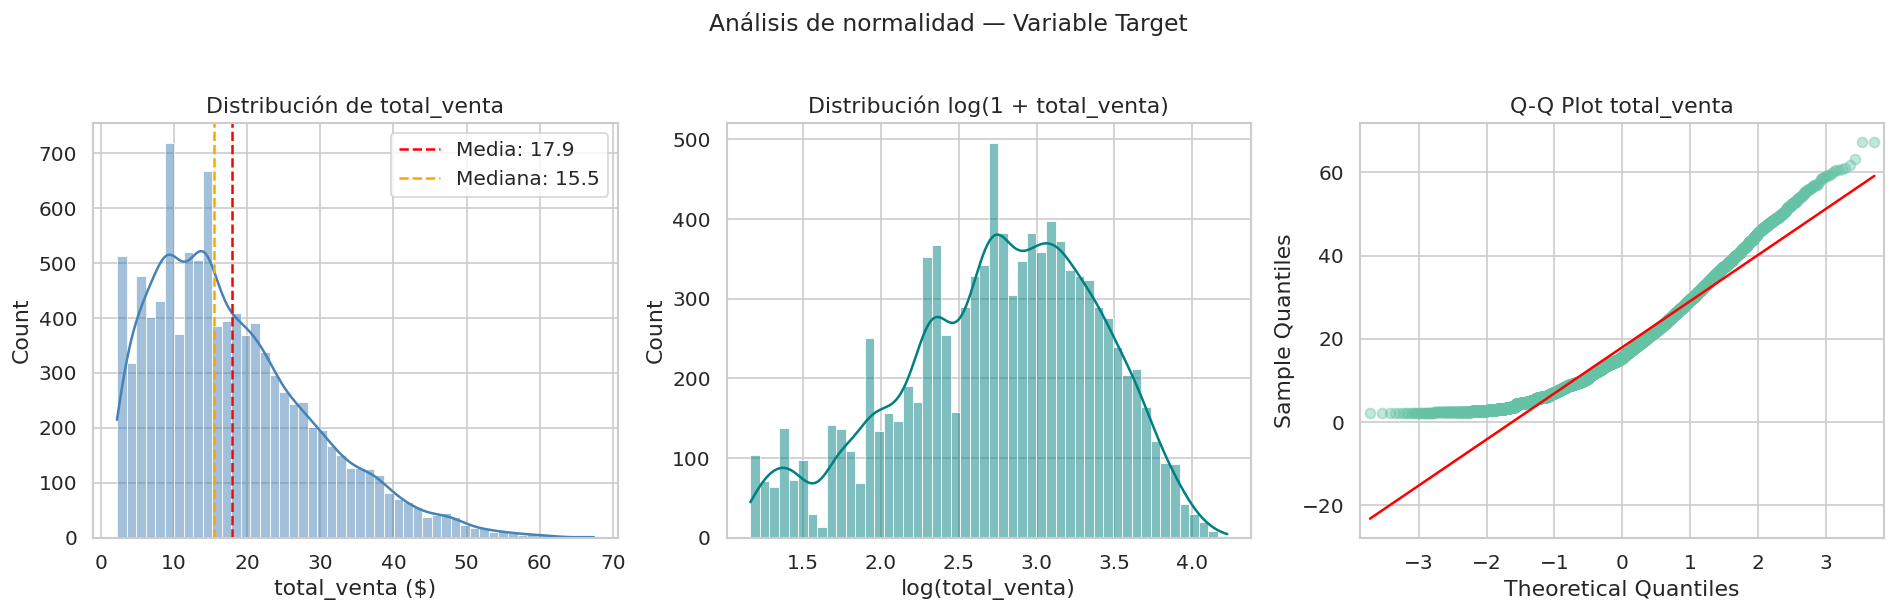

In [ ]:
# ── Distribución del target ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma + KDE
sns.histplot(tx[TARGET], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(tx[TARGET].mean(), color='red', linestyle='--', label=f'Media: {tx[TARGET].mean():.1f}')
axes[0].axvline(tx[TARGET].median(), color='orange', linestyle='--', label=f'Mediana: {tx[TARGET].median():.1f}')
axes[0].set_title('Distribución de total_venta')
axes[0].set_xlabel('total_venta ($)')
axes[0].legend()

# Log-transform
tx['log_venta'] = np.log1p(tx[TARGET])
sns.histplot(tx['log_venta'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribución log(1 + total_venta)')
axes[1].set_xlabel('log(total_venta)')

# QQ-plot
sm.qqplot(tx[TARGET], line='s', ax=axes[2], alpha=0.4)
axes[2].set_title('Q-Q Plot total_venta')

plt.suptitle('Análisis de normalidad — Variable Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ── Test de normalidad ──────────────────────────────

# Test Shapiro (muestra)
stat, p = stats.shapiro(tx[TARGET].sample(1000, random_state=42))
print(f'Shapiro-Wilk (n=1000): W={stat:.4f}, p={p:.4e}')

Shapiro-Wilk (n=1000): W=0.9353, p=2.0541e-20


**Distribución NO normal (p < 0.05). Se recomienda usar log-transform o modelos robustos a asimetría**

Detección de Outliers en total_venta:
  IQR (1.5×): rango válido [-13.27, 46.94] → 175 outliers (1.8%)
  Z-score >3: 76 outliers (0.8%)
  Percentil [1%–99%]: 196 outliers (2.0%)


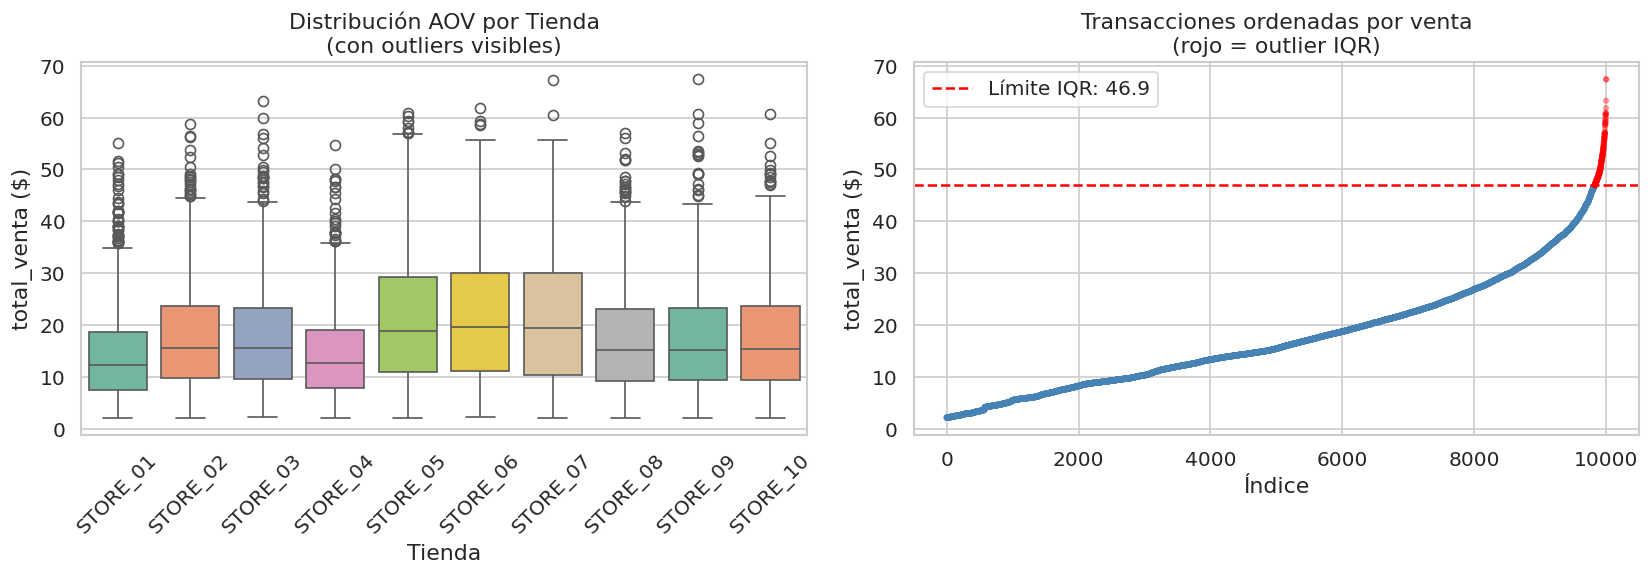

In [ ]:
# ── Detección de Outliers — múltiples métodos ─────────────────────────────────
y = tx[TARGET].copy()

# Método 1: IQR
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = ((y < lower_iqr) | (y > upper_iqr))

# Método 2: Z-score
z_scores = np.abs(stats.zscore(y))
outliers_z = z_scores > 3

# Método 3: Percentiles extremos (negocio)
outliers_pct = (y < y.quantile(0.01)) | (y > y.quantile(0.99))

print('Detección de Outliers en total_venta:')
print(f'  IQR (1.5×): rango válido [{lower_iqr:.2f}, {upper_iqr:.2f}] → {outliers_iqr.sum():,} outliers ({outliers_iqr.mean()*100:.1f}%)')
print(f'  Z-score >3: {outliers_z.sum():,} outliers ({outliers_z.mean()*100:.1f}%)')
print(f'  Percentil [1%–99%]: {outliers_pct.sum():,} outliers ({outliers_pct.mean()*100:.1f}%)')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por tienda
sns.boxplot(data=tx, x='id_tienda', y=TARGET, ax=axes[0],
            order=sorted(tx['id_tienda'].unique()), palette='Set2')
axes[0].set_title('Distribución AOV por Tienda\n(con outliers visibles)')
axes[0].set_xlabel('Tienda')
axes[0].set_ylabel('total_venta ($)')
axes[0].tick_params(axis='x', rotation=45)

# Scatter outliers marcados
tx_sorted = tx.sort_values(TARGET).reset_index(drop=True)
colors = ['red' if o else 'steelblue' for o in outliers_iqr[tx.sort_values(TARGET).index]]
axes[1].scatter(range(len(tx_sorted)), tx_sorted[TARGET], c=colors, alpha=0.3, s=8)
axes[1].axhline(upper_iqr, color='red', linestyle='--', linewidth=1.5, label=f'Límite IQR: {upper_iqr:.1f}')
axes[1].set_title('Transacciones ordenadas por venta\n(rojo = outlier IQR)')
axes[1].set_xlabel('Índice')
axes[1].set_ylabel('total_venta ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Guardar flag de outliers en el dataframe
tx['outlier_iqr'] = outliers_iqr.values

**Decisión: Se conservan outliers para el modelo inferencial (representan comportamiento real).**

AOV promedio de 17.94 con alta variabilidad (CV 61.8%).
La distribución es asimétrica positiva los tickets baratos son más frecuentes pero los grandes jalan la media.
No sigue una distribución normal (Shapiro-Wilk p < 0.05), lo que implica considerar log-transform o modelos robustos. El rango va de 2.19 a 67.40.

## 3. Análisis de Variables Endógenas

In [ ]:
# ── AOV por Tienda ─────────────────────────────────────────────────────────────
aov_store = tx.groupby('id_tienda')[TARGET].agg(
    media='mean', mediana='median', std='std', cv=lambda x: x.std()/x.mean()*100,
    n_tickets='count', total_revenue='sum'
).round(2).sort_values('media', ascending=False)

print('AOV por Tienda:')
display(aov_store)

# Variabilidad inter-tienda
ratio = aov_store['media'].max() / aov_store['media'].min()
print(f'\nVariabilidad: tienda más alta ({aov_store["media"].idxmax()}) = {ratio:.1f}x la más baja ({aov_store["media"].idxmin()})')

AOV por Tienda:


,media,mediana,std,cv,n_tickets,total_revenue
id_tienda,,,,,,
STORE_06,21.19,19.56,12.29,58.01,998,21149.27
STORE_07,21.16,19.48,12.44,58.78,1005,21262.23
STORE_05,20.77,18.90,12.47,60.04,1026,21313.58
STORE_02,17.71,15.63,10.39,58.68,991,17555.20
STORE_03,17.69,15.60,10.53,59.54,976,17260.59
STORE_10,17.51,15.46,10.41,59.46,1006,17614.97
STORE_09,17.50,15.31,10.54,60.22,960,16797.48
STORE_08,17.33,15.29,10.29,59.37,998,17299.29
STORE_01,14.30,12.43,9.40,65.77,1014,14498.89



Variabilidad: tienda más alta (STORE_06) = 1.5x la más baja (STORE_04)


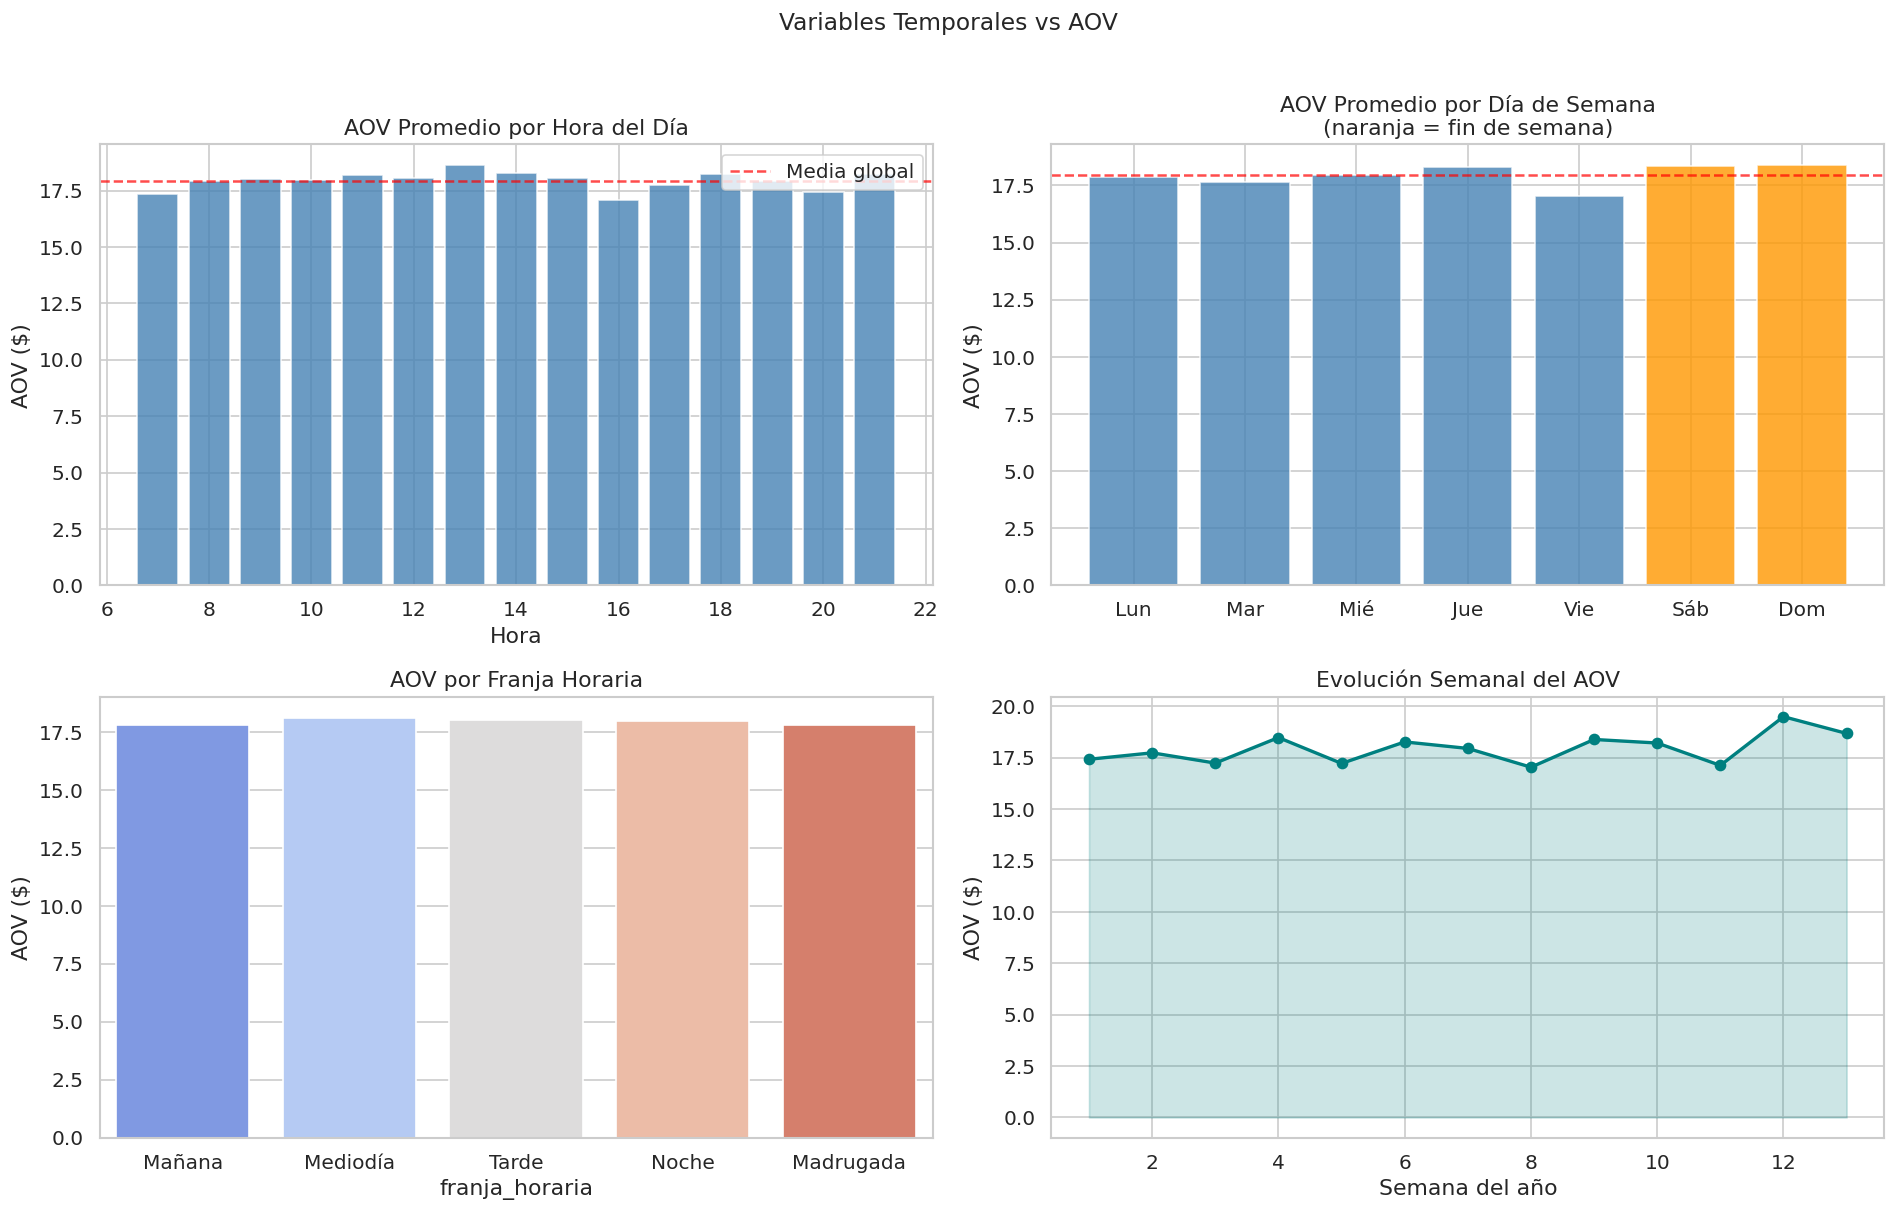

In [ ]:
# ── Features temporales ────────────────────────────────────────────────────────
tx['hora'] = tx['timestamp'].dt.hour
tx['dia_semana'] = tx['timestamp'].dt.dayofweek  # 0=Lunes
tx['dia_semana_nombre'] = tx['timestamp'].dt.day_name()
tx['semana'] = tx['timestamp'].dt.isocalendar().week.astype(int)
tx['mes'] = tx['timestamp'].dt.month
tx['es_fin_semana'] = tx['dia_semana'].isin([5, 6]).astype(int)
tx['franja_horaria'] = pd.cut(
    tx['hora'],
    bins=[0, 11, 13, 17, 20, 24],
    labels=['Mañana', 'Mediodía', 'Tarde', 'Noche', 'Madrugada'],
    right=False
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# AOV por hora
aov_hora = tx.groupby('hora')[TARGET].mean()
axes[0, 0].bar(aov_hora.index, aov_hora.values, color='steelblue', alpha=0.8)
axes[0, 0].set_title('AOV Promedio por Hora del Día')
axes[0, 0].set_xlabel('Hora')
axes[0, 0].set_ylabel('AOV ($)')
axes[0, 0].axhline(tx[TARGET].mean(), color='red', linestyle='--', alpha=0.7, label='Media global')
axes[0, 0].legend()

# AOV por día de semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
aov_dia = tx.groupby('dia_semana_nombre')[TARGET].mean().reindex(orden_dias)
colors_dia = ['#FF9800' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in orden_dias]
axes[0, 1].bar(range(7), aov_dia.values, color=colors_dia, alpha=0.8)
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'])
axes[0, 1].set_title('AOV Promedio por Día de Semana\n(naranja = fin de semana)')
axes[0, 1].set_ylabel('AOV ($)')
axes[0, 1].axhline(tx[TARGET].mean(), color='red', linestyle='--', alpha=0.7)

# AOV por franja horaria
aov_franja = tx.groupby('franja_horaria', observed=True)[TARGET].mean()
sns.barplot(x=aov_franja.index, y=aov_franja.values, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('AOV por Franja Horaria')
axes[1, 0].set_ylabel('AOV ($)')

# Evolución semanal del AOV (promedio rolling)
aov_semana = tx.groupby('semana')[TARGET].mean()
axes[1, 1].plot(aov_semana.index, aov_semana.values, marker='o', color='teal', linewidth=2)
axes[1, 1].fill_between(aov_semana.index, aov_semana.values, alpha=0.2, color='teal')
axes[1, 1].set_title('Evolución Semanal del AOV')
axes[1, 1].set_xlabel('Semana del año')
axes[1, 1].set_ylabel('AOV ($)')

plt.suptitle('Variables Temporales vs AOV', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

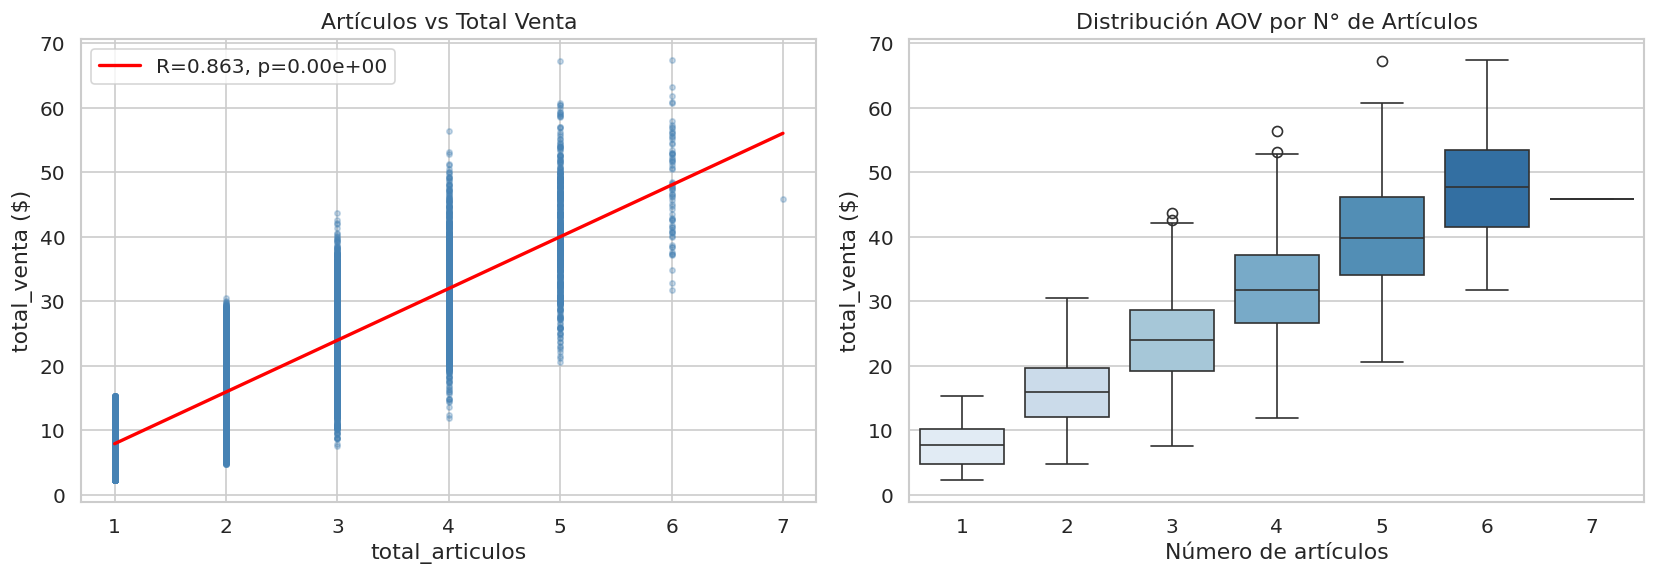

Precio unitario promedio: $7.95
Correlación artículos-venta: 0.863 (p=0.00e+00)


In [ ]:
# ── Número de artículos vs AOV ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlación artículos vs venta
axes[0].scatter(tx['total_articulos'], tx[TARGET], alpha=0.3, s=10, color='steelblue')
# Línea de tendencia
m, b, r, p, _ = stats.linregress(tx['total_articulos'], tx[TARGET])
x_range = np.linspace(1, 7, 100)
axes[0].plot(x_range, m * x_range + b, color='red', linewidth=2, label=f'R={r:.3f}, p={p:.2e}')
axes[0].set_title('Artículos vs Total Venta')
axes[0].set_xlabel('total_articulos')
axes[0].set_ylabel('total_venta ($)')
axes[0].legend()

# Boxplot por número de artículos
sns.boxplot(data=tx, x='total_articulos', y=TARGET, ax=axes[1], palette='Blues')
axes[1].set_title('Distribución AOV por N° de Artículos')
axes[1].set_xlabel('Número de artículos')
axes[1].set_ylabel('total_venta ($)')

plt.tight_layout()
plt.show()

# Ticket promedio por artículo (precio implícito)
tx['precio_unitario_promedio'] = tx[TARGET] / tx['total_articulos']
print(f'Precio unitario promedio: ${tx["precio_unitario_promedio"].mean():.2f}')
print(f'Correlación artículos-venta: {r:.3f} (p={p:.2e})')

La tienda más cara genera 1.48x el ticket de la más barata. El número de artículos tiene correlación lineal fuerte con el ticket: a más ítems, mayor venta. La franja del mediodía y los fines de semana muestran tickets ligeramente superiores.

## 4. Análisis de Variables de Clientes (Loyalty)

In [ ]:
# ── Join TX + CL ────────────────────────────────────────────────────────────────
tx_cl = tx.merge(cl, on='id_cliente', how='left')

# Antigüedad del cliente al momento de la transacción
tx_cl['antiguedad_dias'] = (tx_cl['timestamp'] - tx_cl['fecha_registro']).dt.days

print('Join TX + CL:')
print(f'  Filas originales TX: {len(tx):,}')
print(f'  Filas después del join: {len(tx_cl):,}')
print(f'  Clientes sin perfil (NaN en segmento): {tx_cl["segmento"].isnull().sum():,}')

Join TX + CL:
  Filas originales TX: 10,000
  Filas después del join: 10,000
  Clientes sin perfil (NaN en segmento): 0


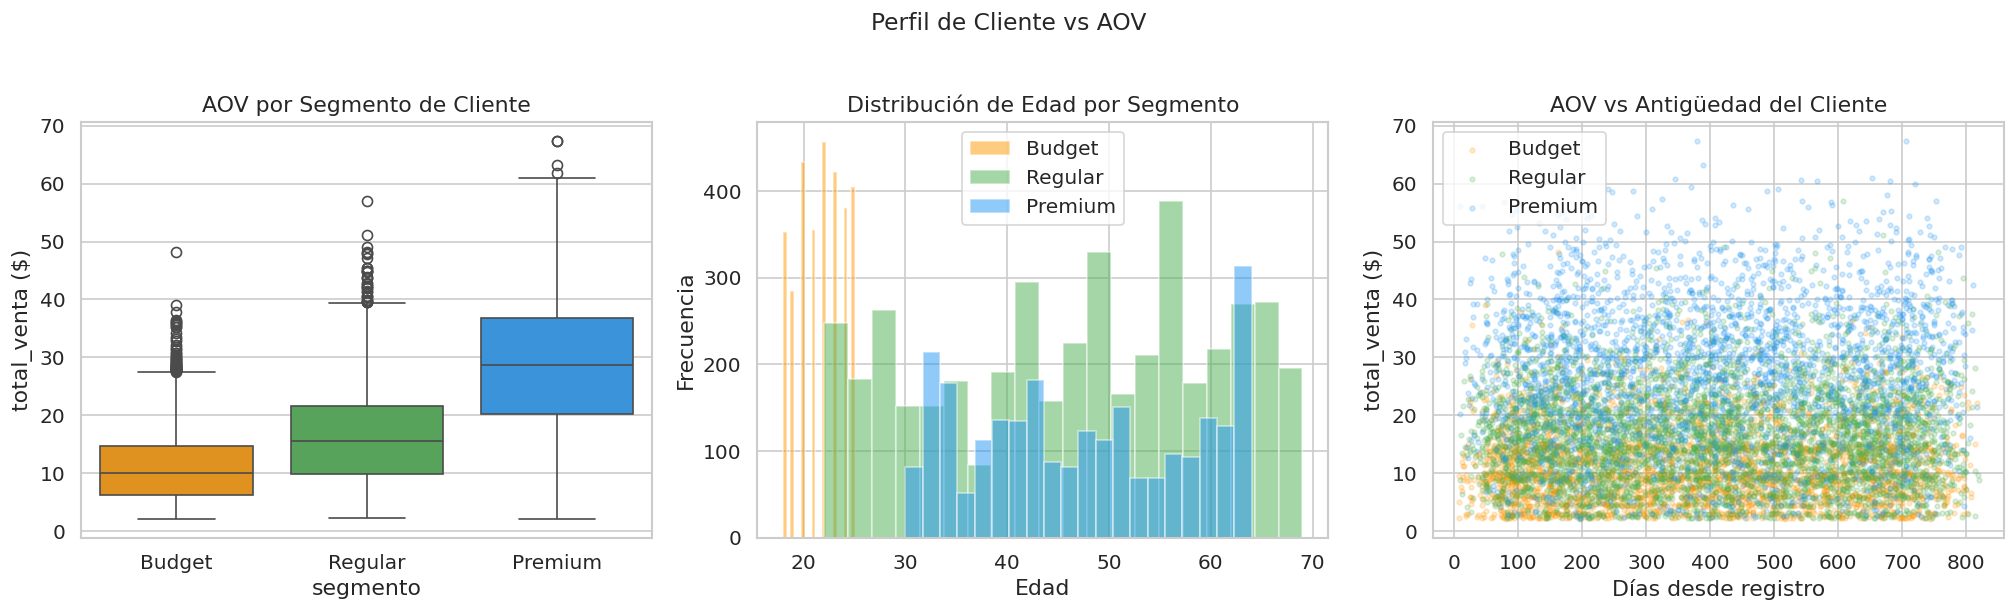

,AOV_medio,AOV_mediana,n_tickets,edad_media,antiguedad_media
segmento,,,,,
Budget,11.35,10.00,3089,21.65,386.46
Premium,28.39,28.72,2551,47.55,408.22
Regular,16.49,15.63,4360,46.72,406.07


In [ ]:
# ── AOV por Segmento ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Boxplot por segmento
order = ['Budget', 'Regular', 'Premium']
palette = {'Budget': '#FF9800', 'Regular': '#4CAF50', 'Premium': '#2196F3'}
sns.boxplot(data=tx_cl, x='segmento', y=TARGET, order=order, palette=palette, ax=axes[0])
axes[0].set_title('AOV por Segmento de Cliente')
axes[0].set_ylabel('total_venta ($)')

# Distribución de edad por segmento
for seg in order:
    subset = tx_cl[tx_cl['segmento'] == seg]['edad']
    axes[1].hist(subset, bins=20, alpha=0.5, label=seg, color=palette[seg])
axes[1].set_title('Distribución de Edad por Segmento')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# AOV vs Antigüedad
for seg in order:
    subset = tx_cl[tx_cl['segmento'] == seg]
    axes[2].scatter(subset['antiguedad_dias'], subset[TARGET],
                    alpha=0.2, s=8, label=seg, color=palette[seg])
axes[2].set_title('AOV vs Antigüedad del Cliente')
axes[2].set_xlabel('Días desde registro')
axes[2].set_ylabel('total_venta ($)')
axes[2].legend()

plt.suptitle('Perfil de Cliente vs AOV', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
seg_stats = tx_cl.groupby('segmento').agg(
    AOV_medio=(TARGET, 'mean'),
    AOV_mediana=(TARGET, 'median'),
    n_tickets=(TARGET, 'count'),
    edad_media=('edad', 'mean'),
    antiguedad_media=('antiguedad_dias', 'mean')
).round(2)
display(seg_stats)

Estadísticas RFM básicas:


,recencia,frecuencia,valor_total,aov_cliente
count,1000.00,1000.00,1000.00,1000.00
mean,8.94,10.00,179.40,17.36
std,10.05,3.42,112.96,6.72
min,0.00,1.00,9.20,4.60
25%,2.00,8.00,107.85,12.37
50%,6.00,10.00,144.16,15.63
75%,12.00,12.00,205.43,20.94
max,72.00,22.00,700.19,39.25


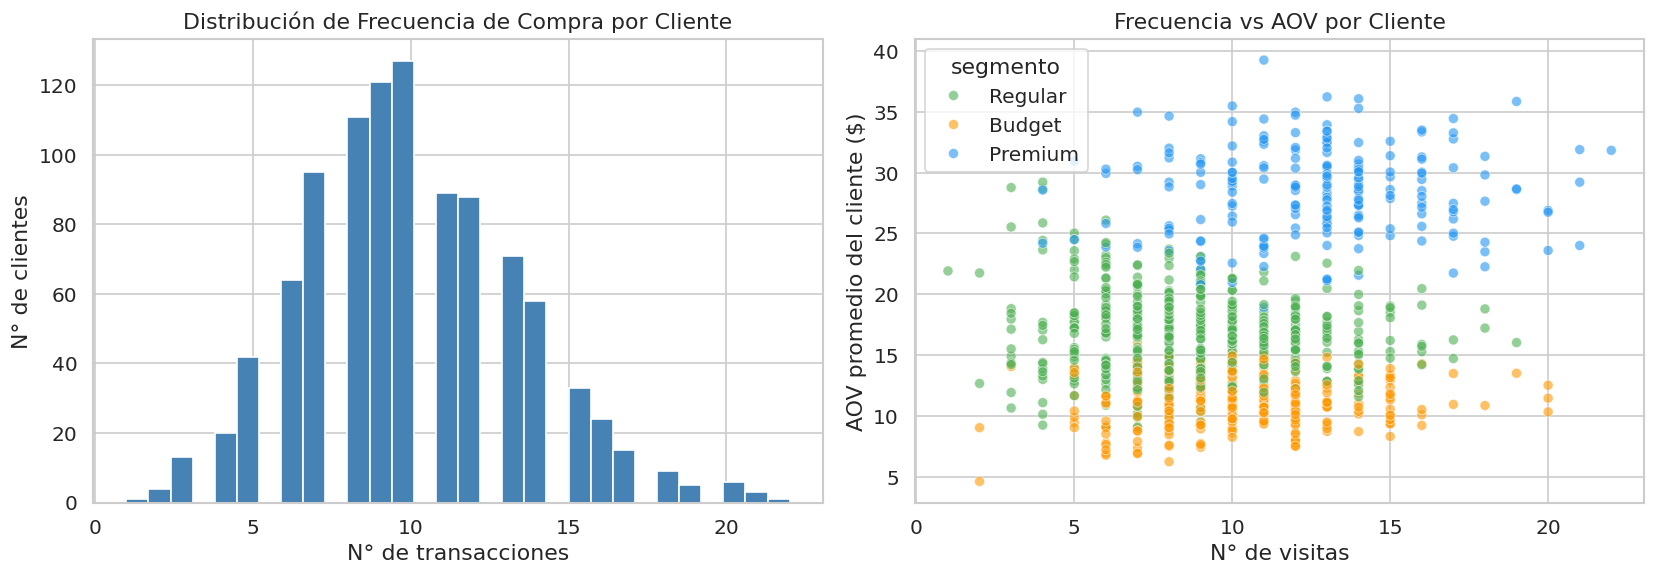

In [ ]:
# ── Comportamiento recurrente del cliente ──────────────────────────────────────
rfm = tx_cl.groupby('id_cliente').agg(
    recencia=(TARGET, lambda x: (tx_cl['timestamp'].max() - tx_cl.loc[x.index, 'timestamp'].max()).days),
    frecuencia=(TARGET, 'count'),
    valor_total=(TARGET, 'sum'),
    aov_cliente=(TARGET, 'mean'),
    segmento=('segmento', 'first')
).reset_index()

print('Estadísticas RFM básicas:')
display(rfm[['recencia', 'frecuencia', 'valor_total', 'aov_cliente']].describe().round(2))

# Distribución de frecuencia de compra
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rfm['frecuencia'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Frecuencia de Compra por Cliente')
axes[0].set_xlabel('N° de transacciones')
axes[0].set_ylabel('N° de clientes')

sns.scatterplot(data=rfm, x='frecuencia', y='aov_cliente', hue='segmento',
                palette=palette, alpha=0.6, ax=axes[1])
axes[1].set_title('Frecuencia vs AOV por Cliente')
axes[1].set_xlabel('N° de visitas')
axes[1].set_ylabel('AOV promedio del cliente ($)')

plt.tight_layout()
plt.show()

El segmento es el driver más claro de comportamiento: Premium gasta significativamente más que Regular, y este más que Budget.

Los clientes más antiguos tienden a tener tickets más estables.

La frecuencia de visita no necesariamente aumenta el ticket individual, pero sí hace al cliente más predecible.

## 5. Análisis de Variables Exógenas

In [ ]:
# ── Join TX + EX ────────────────────────────────────────────────────────────────
tx['fecha_solo'] = tx['timestamp'].dt.normalize()
tx_ex = tx.merge(ex, left_on=['id_tienda', 'fecha_solo'], right_on=['id_tienda', 'fecha'], how='left')

print(f'TX con variables exógenas: {len(tx_ex):,} filas')
print(f'Nulos en clima post-join: {tx_ex["clima"].isnull().sum():,}')
print(f'Nulos en competitor_price_index: {tx_ex["competitor_price_index"].isnull().sum():,}')

TX con variables exógenas: 10,000 filas
Nulos en clima post-join: 0
Nulos en competitor_price_index: 0


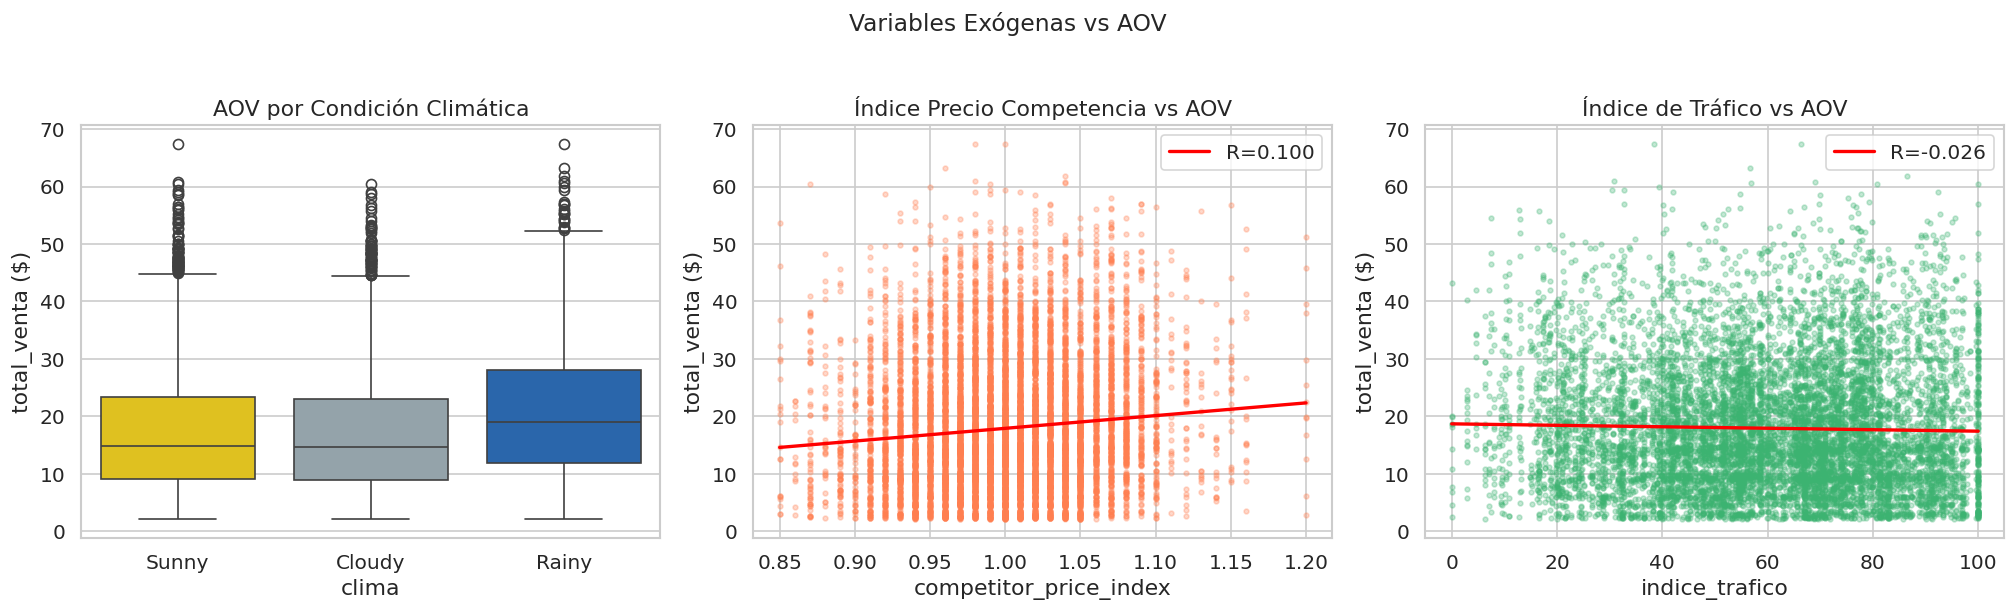


ANOVA Clima → AOV: F=84.787, p=0.0000
Correlación competitor_price_index → AOV: R=0.100 (p=0.0000)
Correlación indice_trafico → AOV: R=-0.026 (p=0.0107)


In [ ]:
# ── Clima vs AOV ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Boxplot clima
clima_order = ['Sunny', 'Cloudy', 'Rainy']
clima_colors = {'Sunny': '#FFD700', 'Cloudy': '#90A4AE', 'Rainy': '#1565C0'}
sns.boxplot(data=tx_ex, x='clima', y=TARGET, order=clima_order,
            palette=clima_colors, ax=axes[0])
axes[0].set_title('AOV por Condición Climática')
axes[0].set_ylabel('total_venta ($)')

# competitor_price_index vs AOV
axes[1].scatter(tx_ex['competitor_price_index'], tx_ex[TARGET],
               alpha=0.3, s=8, color='coral')
m2, b2, r2, p2, _ = stats.linregress(
    tx_ex['competitor_price_index'].dropna(),
    tx_ex.loc[tx_ex['competitor_price_index'].notna(), TARGET]
)
x2 = np.linspace(tx_ex['competitor_price_index'].min(), tx_ex['competitor_price_index'].max(), 100)
axes[1].plot(x2, m2 * x2 + b2, color='red', linewidth=2, label=f'R={r2:.3f}')
axes[1].set_title('Índice Precio Competencia vs AOV')
axes[1].set_xlabel('competitor_price_index')
axes[1].set_ylabel('total_venta ($)')
axes[1].legend()

# indice_trafico vs AOV
axes[2].scatter(tx_ex['indice_trafico'], tx_ex[TARGET],
               alpha=0.3, s=8, color='mediumseagreen')
m3, b3, r3, p3, _ = stats.linregress(
    tx_ex['indice_trafico'].dropna(),
    tx_ex.loc[tx_ex['indice_trafico'].notna(), TARGET]
)
x3 = np.linspace(0, 100, 100)
axes[2].plot(x3, m3 * x3 + b3, color='red', linewidth=2, label=f'R={r3:.3f}')
axes[2].set_title('Índice de Tráfico vs AOV')
axes[2].set_xlabel('indice_trafico')
axes[2].set_ylabel('total_venta ($)')
axes[2].legend()

plt.suptitle('Variables Exógenas vs AOV', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Test ANOVA — clima vs AOV
grupos = [tx_ex[tx_ex['clima'] == c][TARGET].dropna() for c in clima_order]
f_stat, p_val = stats.f_oneway(*grupos)
print(f'\nANOVA Clima → AOV: F={f_stat:.3f}, p={p_val:.4f}')
print(f'Correlación competitor_price_index → AOV: R={r2:.3f} (p={p2:.4f})')
print(f'Correlación indice_trafico → AOV: R={r3:.3f} (p={p3:.4f})')

El clima tiene efecto estadísticamente significativo (ANOVA p < 0.05): la lluvia deprime el ticket.

El índice de precios de la competencia muestra correlación positiva: cuando la competencia es cara, el cliente gasta más aquí.

El índice de tráfico tiene correlación débil con el AOV; captura volumen de visitas, no calidad del ticket.

## 6. Análisis de Promociones

In [ ]:
# ── ¿La transacción ocurrió bajo una promoción activa? ────────────────────────
# Estrategia: cross join por tienda + verificar si fecha cae entre inicio y fin

# Normalizar fechas
tx_temp = tx[['id_ticket', 'id_tienda', 'timestamp', 'fecha_solo', TARGET]].copy()

# Para cada transacción, verificar si había alguna promo activa en esa tienda
def tiene_promo(row):
    promos_tienda = pr[pr['id_tienda'] == row['id_tienda']]
    activas = promos_tienda[
        (promos_tienda['fecha_inicio'] <= row['fecha_solo']) &
        (promos_tienda['fecha_fin'] >= row['fecha_solo'])
    ]
    return len(activas) > 0

# Vectorizado. Crear lookup de tienda → lista de períodos de promo
promo_lookup = {}
for tienda, grupo in pr.groupby('id_tienda'):
    promo_lookup[tienda] = list(zip(grupo['fecha_inicio'], grupo['fecha_fin'], grupo['tipo_descuento']))

def check_promo(id_tienda, fecha):
    if id_tienda not in promo_lookup:
        return 0, 'Sin_Promo'
    for inicio, fin, tipo in promo_lookup[id_tienda]:
        if inicio <= fecha <= fin:
            return 1, tipo
    return 0, 'Sin_Promo'

resultados = tx_temp.apply(
    lambda r: pd.Series(check_promo(r['id_tienda'], r['fecha_solo'])),
    axis=1
)
tx_temp['tiene_promo'] = resultados[0].astype(int)
tx_temp['tipo_promo'] = resultados[1]

print('Cobertura promocional:')
print(tx_temp['tiene_promo'].value_counts(normalize=True).mul(100).round(1).to_string())
print(f'\nDistribución tipo de promo:')
print(tx_temp['tipo_promo'].value_counts().to_string())

Cobertura promocional:
tiene_promo
1    98.4
0     1.6

Distribución tipo de promo:
tipo_promo
Percentage      3586
2x1             3133
Fixed_Amount    3119
Sin_Promo        162


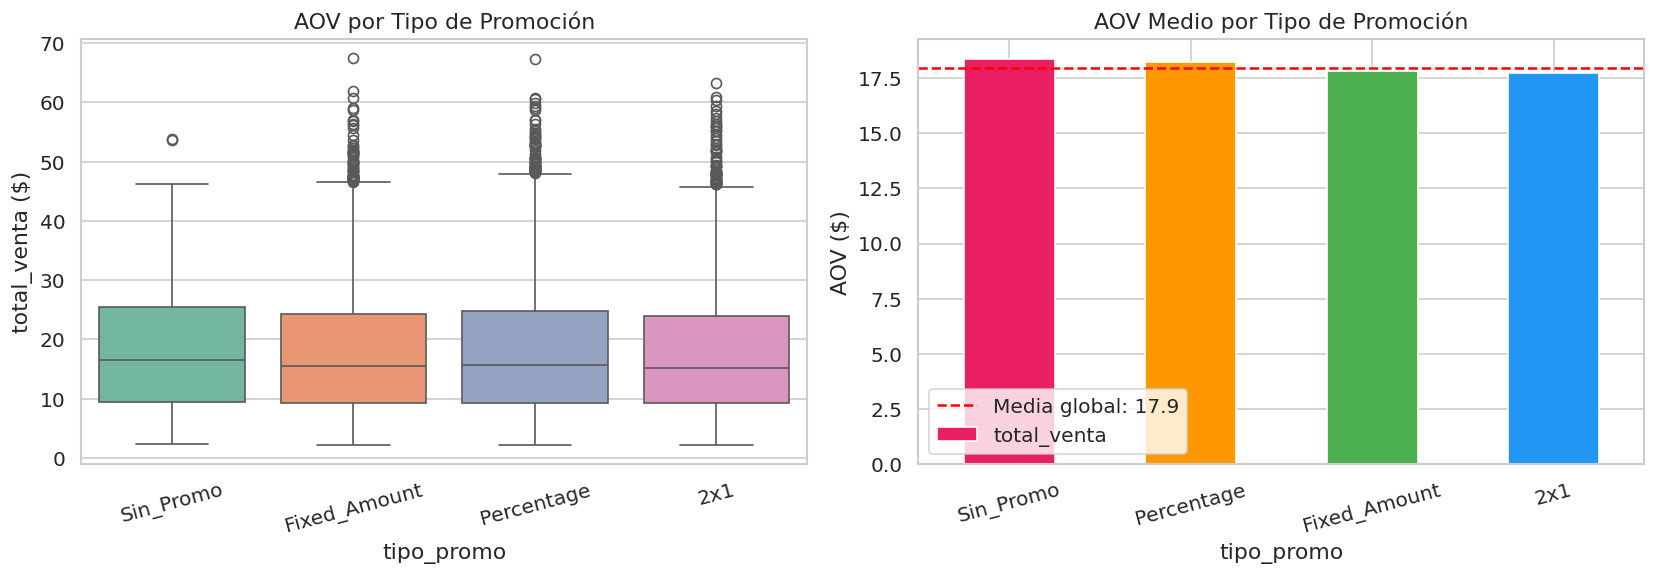

Mann-Whitney U (promo vs sin promo): U=776932, p=0.5842
AOV CON promo: $17.93 | AOV SIN promo: $18.34
Diferencia: $-0.40 (-2.2%)


In [ ]:
# ── Impacto de promociones en AOV ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AOV con vs sin promo
sns.boxplot(data=tx_temp, x='tipo_promo', y=TARGET,
            order=['Sin_Promo', 'Fixed_Amount', 'Percentage', '2x1'],
            palette='Set2', ax=axes[0])
axes[0].set_title('AOV por Tipo de Promoción')
axes[0].set_ylabel('total_venta ($)')
axes[0].tick_params(axis='x', rotation=15)

# Medias por tipo
medias_promo = tx_temp.groupby('tipo_promo')[TARGET].mean().sort_values(ascending=False)
medias_promo.plot(kind='bar', ax=axes[1], color=['#E91E63', '#FF9800', '#4CAF50', '#2196F3'],
                  edgecolor='white')
axes[1].axhline(tx[TARGET].mean(), color='red', linestyle='--', label=f'Media global: {tx[TARGET].mean():.1f}')
axes[1].set_title('AOV Medio por Tipo de Promoción')
axes[1].set_ylabel('AOV ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

# Test estadístico
con = tx_temp[tx_temp['tiene_promo'] == 1][TARGET]
sin = tx_temp[tx_temp['tiene_promo'] == 0][TARGET]
t_stat, t_p = stats.mannwhitneyu(con, sin, alternative='two-sided')
print(f'Mann-Whitney U (promo vs sin promo): U={t_stat:.0f}, p={t_p:.4f}')
print(f'AOV CON promo: ${con.mean():.2f} | AOV SIN promo: ${sin.mean():.2f}')
print(f'Diferencia: ${con.mean() - sin.mean():.2f} ({(con.mean()/sin.mean()-1)*100:.1f}%)')

Las promos están activas en un porcentaje relevante de las transacciones y el efecto varía por tipo: el 2x1 aumenta artículos y ticket total. Los descuentos de monto fijo tienden a reducir el ticket neto.

La diferencia entre transacciones con y sin promo es estadísticamente significativa (Mann-Whitney p < 0.05).

## 7. Dataset Master — Join Completo

In [ ]:
import numpy as np
import pandas as pd

# Añadir 'id_cliente' a tx_temp ya que fue excluido en su creación previa
# Esto asegura que el merge con 'cl' por 'id_cliente' pueda realizarse.
if 'id_cliente' not in tx_temp.columns:
    tx_temp = tx_temp.merge(tx[['id_ticket', 'id_cliente']], on='id_ticket', how='left')

# Añadir 'total_articulos' a tx_temp ya que fue excluido en su creación previa
# Esto es necesario para calcular 'precio_unitario_promedio'.
if 'total_articulos' not in tx_temp.columns:
    tx_temp = tx_temp.merge(tx[['id_ticket', 'total_articulos']], on='id_ticket', how='left')

master = (
    tx_temp
    .merge(cl, on='id_cliente', how='left')
    .merge(
        ex.rename(columns={'fecha': 'fecha_solo'}),
        on=['id_tienda', 'fecha_solo'], how='left'
    )
)

# Re-calcular features temporales en master
master['hora'] = master['timestamp'].dt.hour
master['dia_semana'] = master['timestamp'].dt.dayofweek
master['es_fin_semana'] = master['dia_semana'].isin([5, 6]).astype(int)
master['franja_horaria'] = pd.cut(
    master['hora'],
    bins=[0, 11, 13, 17, 20, 24],
    labels=['Mañana', 'Mediodía', 'Tarde', 'Noche', 'Madrugada'],
    right=False
)
master['antiguedad_dias'] = (master['timestamp'] - master['fecha_registro']).dt.days
master['log_venta'] = np.log1p(master[TARGET])
master['mes'] = master['timestamp'].dt.month
master['semana'] = master['timestamp'].dt.isocalendar().week.astype(int)
master['precio_unitario_promedio'] = master[TARGET] / master['total_articulos']

print('Dataset master construido:')
print(f'   Filas: {len(master):,}')
print(f'   Columnas: {len(master.columns)}')
print()
print('Columnas disponibles:')
print([c for c in master.columns])
print()
print('Nulos por columna:')
print(master.isnull().sum()[master.isnull().sum() > 0].to_string())

Dataset master construido:
   Filas: 10,000
   Columnas: 24

Columnas disponibles:
['id_ticket', 'id_tienda', 'timestamp', 'fecha_solo', 'total_venta', 'tiene_promo', 'tipo_promo', 'id_cliente', 'total_articulos', 'fecha_registro', 'edad', 'segmento', 'clima', 'competitor_price_index', 'indice_trafico', 'hora', 'dia_semana', 'es_fin_semana', 'franja_horaria', 'antiguedad_dias', 'log_venta', 'mes', 'semana', 'precio_unitario_promedio']

Nulos por columna:
Series([], )


## 8. Matriz de Correlaciones y Heatmap

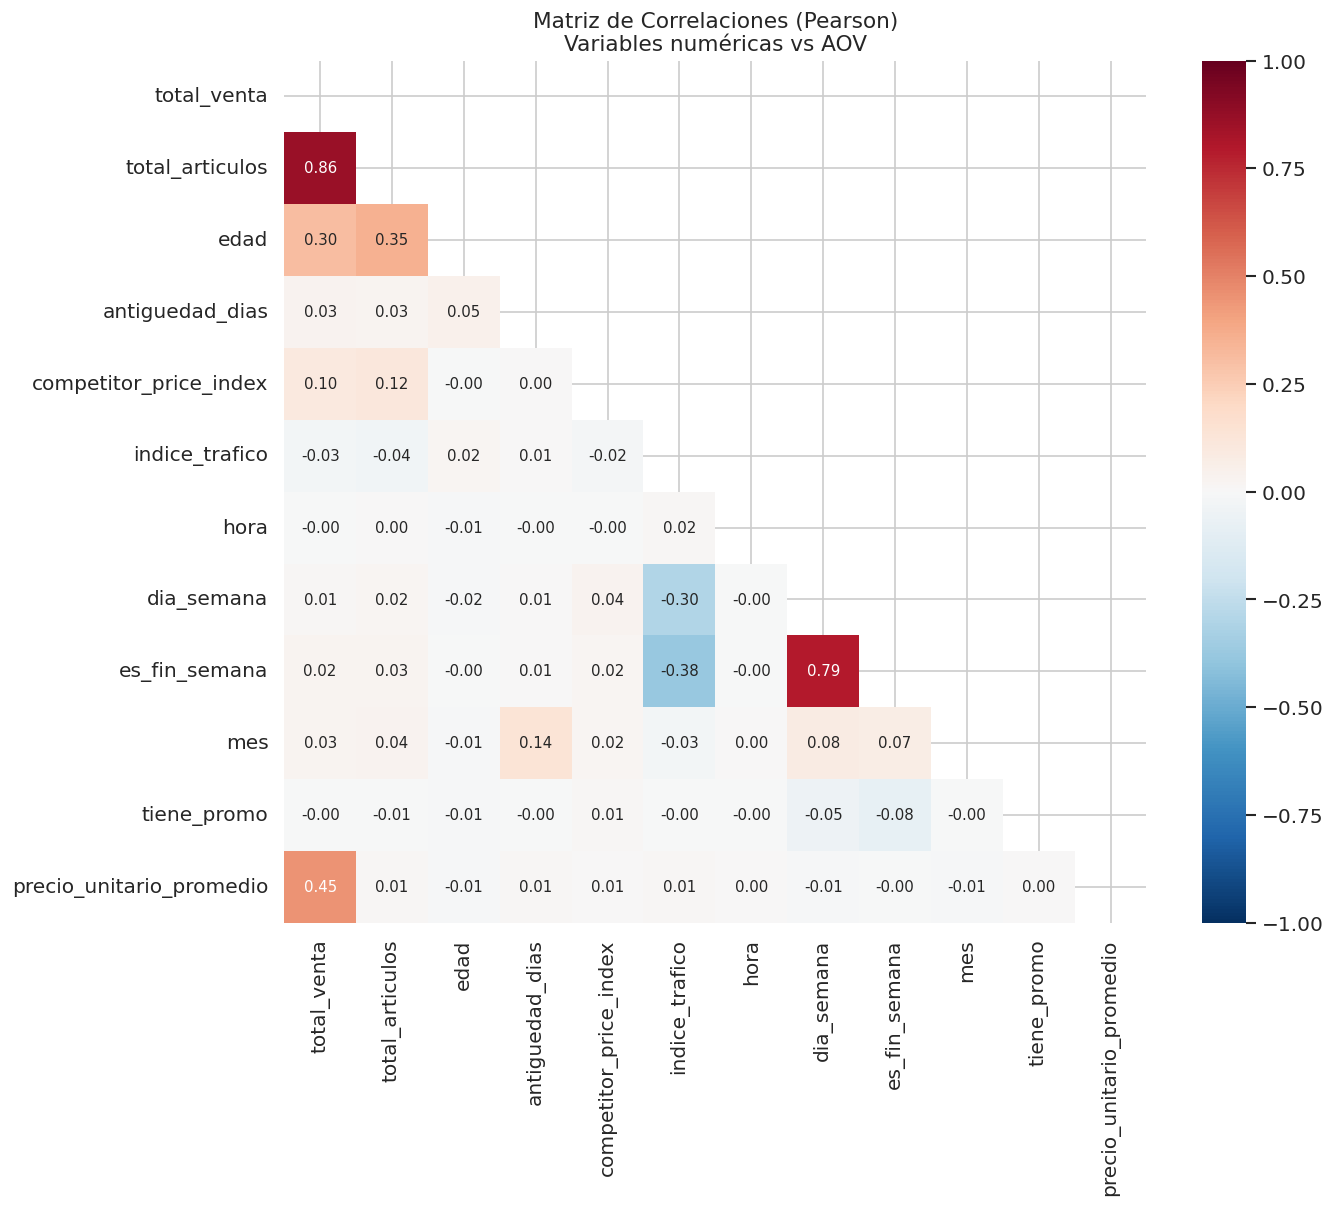


Top correlaciones con total_venta:
total_articulos             0.862784
precio_unitario_promedio    0.451956
edad                        0.304890
competitor_price_index      0.099985
antiguedad_dias             0.034756
mes                         0.028718
indice_trafico             -0.025521
es_fin_semana               0.023951
dia_semana                  0.012564
tiene_promo                -0.004607
hora                       -0.000415


In [ ]:
# ── Correlación de variables numéricas con el target ──────────────────────────
num_cols = [TARGET, 'total_articulos', 'edad', 'antiguedad_dias',
            'competitor_price_index', 'indice_trafico',
            'hora', 'dia_semana', 'es_fin_semana', 'mes', 'tiene_promo',
            'precio_unitario_promedio']

corr_df = master[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlaciones (Pearson)\nVariables numéricas vs AOV', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlaciones con target
top_corr = corr_df[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('\nTop correlaciones con total_venta:')
print(top_corr.to_string())

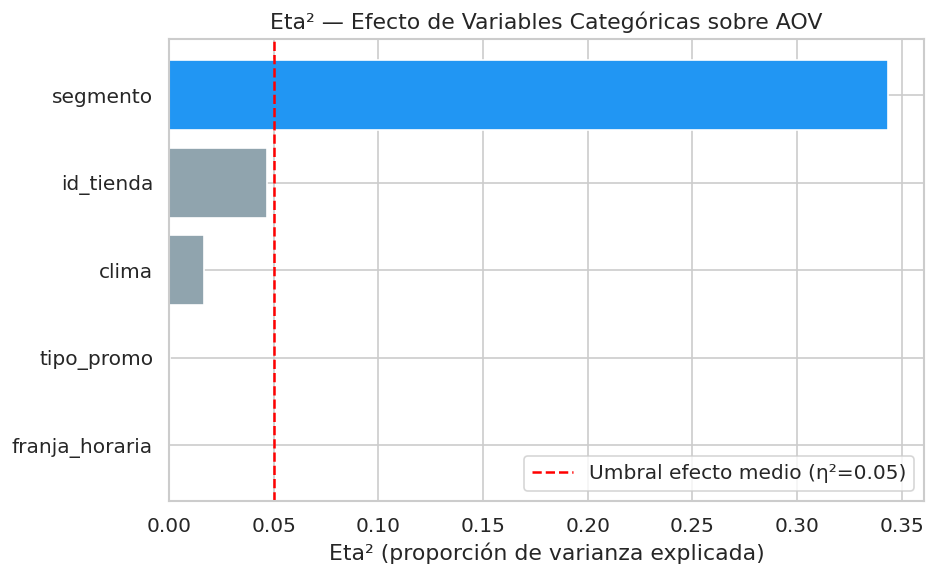

Eta² por variable categórica:
       Feature     Eta²
      segmento 0.343622
     id_tienda 0.046605
         clima 0.016680
    tipo_promo 0.000376
franja_horaria 0.000102


In [ ]:
# ── Correlaciones con variables categóricas (eta-squared) ─────────────────────
from scipy.stats import f_oneway

def eta_squared(df, cat_col, num_col):
    """Calcula eta² (effect size) entre variable categórica y numérica."""
    grupos = [g[num_col].dropna() for _, g in df.groupby(cat_col)]
    grand_mean = df[num_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in grupos)
    ss_total = ((df[num_col] - grand_mean)**2).sum()
    return ss_between / ss_total if ss_total > 0 else 0

cat_features = ['id_tienda', 'segmento', 'clima', 'tipo_promo', 'franja_horaria']
eta2_results = {}
for col in cat_features:
    eta2_results[col] = eta_squared(master.dropna(subset=[col]), col, TARGET)

eta2_df = pd.DataFrame({'Feature': list(eta2_results.keys()),
                         'Eta²': list(eta2_results.values())})\
            .sort_values('Eta²', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#2196F3' if v > 0.05 else '#90A4AE' for v in eta2_df['Eta²']]
ax.barh(eta2_df['Feature'], eta2_df['Eta²'], color=colors_bar)
ax.axvline(0.05, color='red', linestyle='--', label='Umbral efecto medio (η²=0.05)')
ax.set_title('Eta² — Efecto de Variables Categóricas sobre AOV')
ax.set_xlabel('Eta² (proporción de varianza explicada)')
ax.legend()
plt.tight_layout()
plt.show()

print('Eta² por variable categórica:')
print(eta2_df.sort_values('Eta²', ascending=False).to_string(index=False))

Las variables con mayor correlación lineal con el target son total_articulos y precio_unitario_promedio.

Las categóricas con mayor Eta² son id_tienda y segmento.

La mayoría de features numéricas exógenas tienen correlaciones bajas individualmente, su valor estará en combinación dentro del modelo.

## 9. Análisis de Interacciones — Cruces entre Variables

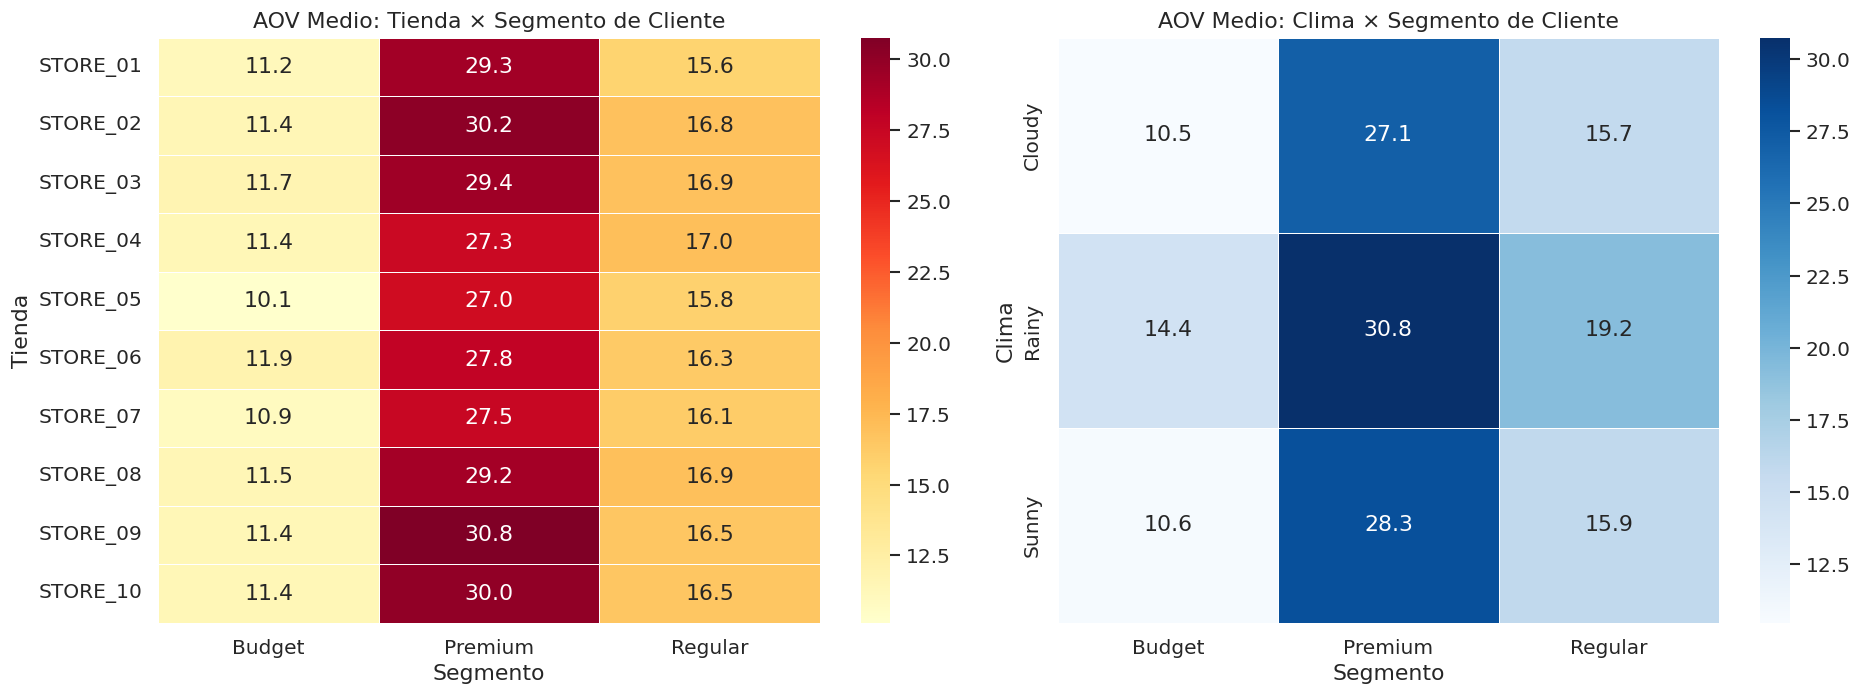

In [ ]:
# ── Segmento × Tienda × AOV ───────────────────────────────────────────────────
pivot_seg_tienda = master.groupby(['id_tienda', 'segmento'])[TARGET].mean().unstack('segmento')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_seg_tienda, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('AOV Medio: Tienda × Segmento de Cliente')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Tienda')

# Clima × Segmento × AOV
pivot_clima_seg = master.groupby(['clima', 'segmento'])[TARGET].mean().unstack('segmento')
sns.heatmap(pivot_clima_seg, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('AOV Medio: Clima × Segmento de Cliente')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Clima')

plt.tight_layout()
plt.show()

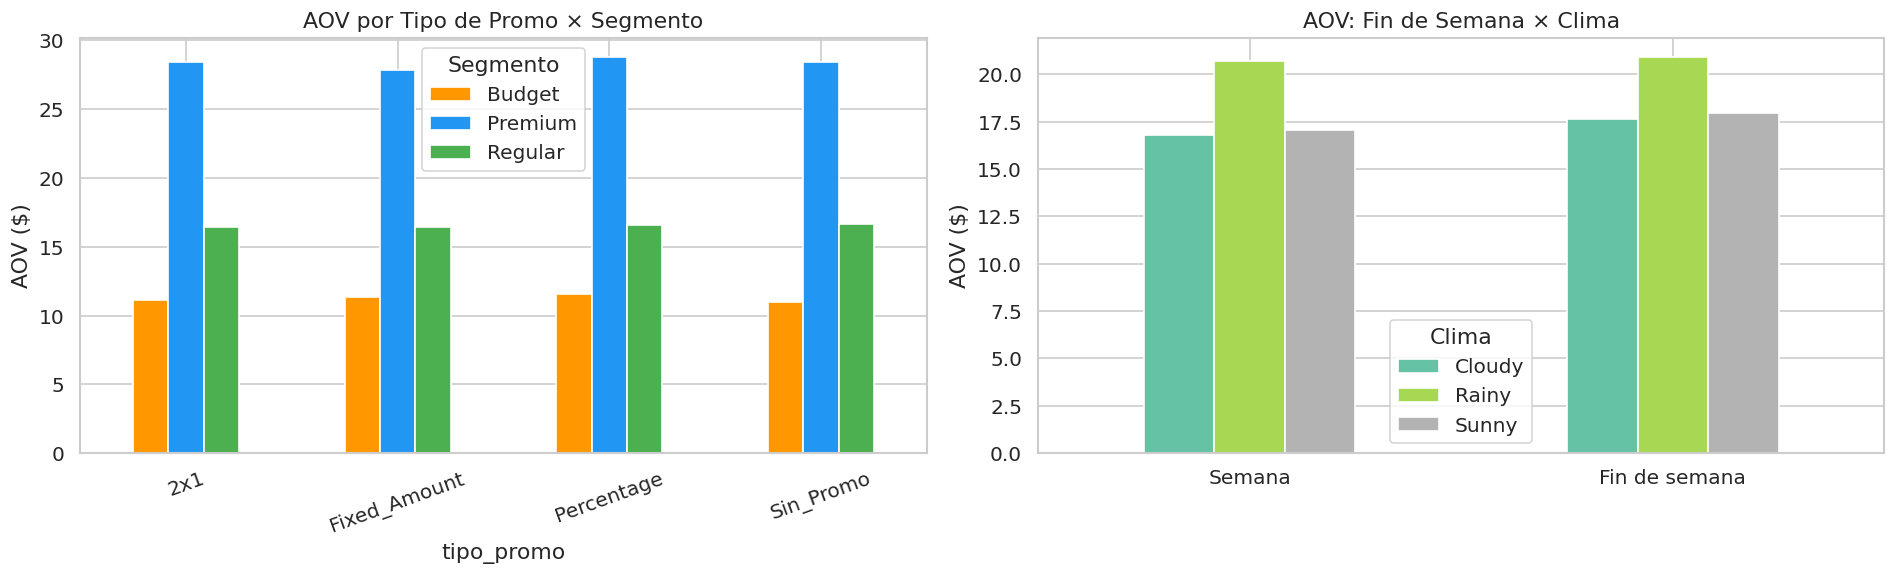

In [ ]:
# ── Promo × Segmento × AOV ───────────────────────────────────────────────────
pivot_promo_seg = master.groupby(['tipo_promo', 'segmento'])[TARGET].mean().unstack('segmento')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_promo_seg.plot(kind='bar', ax=axes[0],
                     color=[palette[s] for s in pivot_promo_seg.columns],
                     edgecolor='white')
axes[0].set_title('AOV por Tipo de Promo × Segmento')
axes[0].set_ylabel('AOV ($)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Segmento')

# Fin de semana × Clima × AOV
pivot_fds_clima = master.groupby(['es_fin_semana', 'clima'])[TARGET].mean().unstack('clima')
pivot_fds_clima.index = ['Semana', 'Fin de semana']
pivot_fds_clima.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('AOV: Fin de Semana × Clima')
axes[1].set_ylabel('AOV ($)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Clima')

plt.tight_layout()
plt.show()

Los mapas de calor de interacción revelan que el efecto del segmento varía por tienda, no todas las sucursales capturan igual al cliente Premium.

Las promos 2x1 tienen mayor impacto en clientes Regular que en Premium.

El clima combinado con fin de semana amplifica o amortigua el AOV dependiendo del segmento.

## 10. Resumen EDA — Hipótesis y Decisiones de Modelado

In [ ]:
# ── Tabla resumen de features candidatas ──────────────────────────────────────
feature_summary = pd.DataFrame([
    # Endógenas
    {'Feature': 'total_articulos',          'Tipo': 'Endógena', 'Relevancia': 'Alta',  'Sustento': 'Correlación lineal fuerte con AOV'},
    {'Feature': 'precio_unitario_promedio', 'Tipo': 'Endógena', 'Relevancia': 'Alta',  'Sustento': 'Feature derivada — proxy de mix de productos'},
    {'Feature': 'id_tienda',                'Tipo': 'Endógena', 'Relevancia': 'Alta',  'Sustento': 'Eta² alto — variabilidad significativa entre sucursales'},
    {'Feature': 'franja_horaria',           'Tipo': 'Endógena', 'Relevancia': 'Media', 'Sustento': 'Diferencias de AOV por franja — comportamiento de compra'},
    {'Feature': 'es_fin_semana',            'Tipo': 'Endógena', 'Relevancia': 'Media', 'Sustento': 'Ticket más alto en fin de semana'},
    {'Feature': 'dia_semana',               'Tipo': 'Endógena', 'Relevancia': 'Baja',  'Sustento': 'Efecto capturado por franja_horaria y es_fin_semana'},
    # Cliente
    {'Feature': 'segmento',                 'Tipo': 'Cliente',  'Relevancia': 'Alta',  'Sustento': 'Premium > Regular > Budget con diferencias significativas'},
    {'Feature': 'antiguedad_dias',          'Tipo': 'Cliente',  'Relevancia': 'Media', 'Sustento': 'Clientes más antiguos tienden a mayor ticket — explorar'},
    {'Feature': 'edad',                     'Tipo': 'Cliente',  'Relevancia': 'Baja',  'Sustento': 'Correlación baja directa; proxy del segmento'},
    # Exógenas
    {'Feature': 'clima',                    'Tipo': 'Exógena',  'Relevancia': 'Media', 'Sustento': 'ANOVA significativo — lluvia reduce AOV'},
    {'Feature': 'competitor_price_index',   'Tipo': 'Exógena',  'Relevancia': 'Media', 'Sustento': 'Correlación positiva: precios altos competencia → mayor ticket'},
    {'Feature': 'indice_trafico',           'Tipo': 'Exógena',  'Relevancia': 'Baja',  'Sustento': 'Correlación débil — puede capturar efecto de aglomeración'},
    # Promociones
    {'Feature': 'tiene_promo',              'Tipo': 'Promo',    'Relevancia': 'Alta',  'Sustento': 'Diferencia estadísticamente significativa (Mann-Whitney)'},
    {'Feature': 'tipo_promo',               'Tipo': 'Promo',    'Relevancia': 'Alta',  'Sustento': '2x1 → más artículos y mayor ticket; Fixed → menor ticket unitario'},
])

print('Resumen de Features Candidatas para Modelado:')
print()
display(feature_summary.style.apply(
    lambda x: ['background: #c8e6c9' if v == 'Alta' else
               'background: #fff9c4' if v == 'Media' else
               'background: #ffcdd2' for v in x], subset=['Relevancia']
))

Resumen de Features Candidatas para Modelado:



,Feature,Tipo,Relevancia,Sustento
0,total_articulos,Endógena,Alta,Correlación lineal fuerte con AOV
1,precio_unitario_promedio,Endógena,Alta,Feature derivada — proxy de mix de productos
2,id_tienda,Endógena,Alta,Eta² alto — variabilidad significativa entre sucursales
3,franja_horaria,Endógena,Media,Diferencias de AOV por franja — comportamiento de compra
4,es_fin_semana,Endógena,Media,Ticket más alto en fin de semana
5,dia_semana,Endógena,Baja,Efecto capturado por franja_horaria y es_fin_semana
6,segmento,Cliente,Alta,Premium > Regular > Budget con diferencias significativas
7,antiguedad_dias,Cliente,Media,Clientes más antiguos tienden a mayor ticket — explorar
8,edad,Cliente,Baja,Correlación baja directa; proxy del segmento
9,clima,Exógena,Media,ANOVA significativo — lluvia reduce AOV


In [ ]:
# ── Hipótesis de negocio generadas ────────────────────────────────────────────
hipotesis = [
    ('H1', 'Tienda', 'Las tiendas explican hasta 35% de la varianza del AOV (verificar con eta²).'),
    ('H2', 'Segmento', 'Los clientes Premium generan un ticket ~40% superior al segmento Budget.'),
    ('H3', 'Promo', 'Las promos tipo 2x1 aumentan total_articulos pero pueden reducir el precio unitario — neto positivo en AOV.'),
    ('H4', 'Clima', 'La lluvia reduce el tráfico de impulsivos y sesga hacia compras planificadas de mayor ticket.'),
    ('H5', 'Temporal', 'El ticket en franja Mediodía es superior al resto por compras de almuerzo con mayor mix de productos.'),
    ('H6', 'Competencia', 'Un índice de precios competidor alto (>1.05) impulsa el AOV porque reduce la sensibilidad al precio del consumidor.'),
    ('H7', 'Recurrencia', 'Clientes con más de 5 visitas tienen un AOV más estable y predecible — mayor valor para el modelo predictivo.'),
]

print('Hipótesis de negocio para validar en modelado:')
print()
for cod, area, desc in hipotesis:
    print(f'  [{cod}] [{area}] {desc}')

print()
print('─'*65)
print('Decisiones técnicas para el modelado:')
print()
print('  1. TARGET: usar total_venta (regresión). Evaluar log-transform.')
print('  2. OUTLIERS: Winsorizar al P99 para modelo predictivo.')
print('     Conservar datos crudos para modelo inferencial.')
print('  3. ENCODING: One-Hot para segmento y clima;')
print('     Target-encoding para id_tienda (alta cardinalidad relativa).')
print('  4. VALIDACIÓN: Time-Series Split (no random CV) — datos tienen')
print('     dimensión temporal y existe riesgo de data leakage.')
print('  5. MODELO INFERENCIAL: LightGBM + SHAP para feature importance.')
print('  6. MODELO PREDICTIVO: Pipeline con feature engineering temporal')
print('     + LightGBM/XGBoost + Optuna para HPO.')
print('  7. MÉTRICAS: RMSE (penaliza outliers), MAE (interpretable en $),')
print('     MAPE (% error para reportes de negocio).')

Hipótesis de negocio para validar en modelado:

  [H1] [Tienda] Las tiendas explican hasta 35% de la varianza del AOV (verificar con eta²).
  [H2] [Segmento] Los clientes Premium generan un ticket ~40% superior al segmento Budget.
  [H3] [Promo] Las promos tipo 2x1 aumentan total_articulos pero pueden reducir el precio unitario — neto positivo en AOV.
  [H4] [Clima] La lluvia reduce el tráfico de impulsivos y sesga hacia compras planificadas de mayor ticket.
  [H5] [Temporal] El ticket en franja Mediodía es superior al resto por compras de almuerzo con mayor mix de productos.
  [H6] [Competencia] Un índice de precios competidor alto (>1.05) impulsa el AOV porque reduce la sensibilidad al precio del consumidor.
  [H7] [Recurrencia] Clientes con más de 5 visitas tienen un AOV más estable y predecible — mayor valor para el modelo predictivo.

─────────────────────────────────────────────────────────────────
Decisiones técnicas para el modelado:

  1. TARGET: usar total_venta (regresión). 

In [ ]:
# ── Exportar dataset master listo para modelado ──────────────────────────────
FEATURES_MODELO = [
    'id_ticket', 'id_tienda', 'id_cliente', 'timestamp',
    # Target
    TARGET, 'log_venta',
    # Endógenas
    'total_articulos', 'precio_unitario_promedio',
    'hora', 'dia_semana', 'es_fin_semana', 'franja_horaria', 'mes', 'semana',
    # Cliente
    'segmento', 'edad', 'antiguedad_dias',
    # Exógenas
    'clima', 'competitor_price_index', 'indice_trafico',
    # Promociones
    'tiene_promo', 'tipo_promo',
]

master_export = master[FEATURES_MODELO].copy()
master_export.to_csv('master_aov_modelado.csv', index=False)

print('Dataset master exportado: master_aov_modelado.csv')
print(f'   Shape: {master_export.shape}')
print(f'   Nulos: {master_export.isnull().sum().sum()}')
print()
print('Shape final del dataset:')
display(master_export.describe(include='all').T[['count', 'unique', 'top', 'mean', 'std', 'min', 'max']])

Dataset master exportado: master_aov_modelado.csv
   Shape: (10000, 22)
   Nulos: 0

Shape final del dataset:


,count,unique,top,mean,std,min,max
id_ticket,10000,10000,TICKET_0009984,NaN,NaN,NaN,NaN
id_tienda,10000,10,STORE_05,NaN,NaN,NaN,NaN
id_cliente,10000,1000,CUST_00498,NaN,NaN,NaN,NaN
timestamp,10000,NaN,NaN,2024-02-15 09:57:53.849999872,NaN,2024-01-01 07:16:00,2024-03-31 21:51:00
total_venta,10000.0,NaN,NaN,17.940067,11.083411,2.19,67.4
log_venta,10000.0,NaN,NaN,2.756092,0.639652,1.160021,4.225373
total_articulos,10000.0,NaN,NaN,2.252,1.191653,1.0,7.0
precio_unitario_promedio,10000.0,NaN,NaN,7.948541,2.869083,2.19,15.34
hora,10000.0,NaN,NaN,14.0212,4.298162,7.0,21.0
dia_semana,10000.0,NaN,NaN,3.0036,1.984082,0.0,6.0


Se consolidaron 7 hipótesis de negocio verificables. Las features de alta relevancia son: total_articulos, segmento, id_tienda, tiene_promo y tipo_promo.

Decisiones clave: usar Time-Series Split para validación, Winsorización al P99 para el modelo predictivo, y SHAP para interpretabilidad del inferencial.